[*********************100%***********************]  9 of 9 completed


Data shape: (11133, 6)
        Date       Ticker  Adj Close       Open       High        Low
0 2021-03-25  ASHOKLEY.NS  50.191471  56.224998  56.349998  53.625000
1 2021-03-26  ASHOKLEY.NS  52.134224  55.750000  57.650002  55.549999
2 2021-03-30  ASHOKLEY.NS  51.951370  57.750000  57.875000  55.849998
3 2021-03-31  ASHOKLEY.NS  51.882805  56.849998  58.000000  56.299999
4 2021-04-01  ASHOKLEY.NS  54.008400  57.625000  59.375000  56.750000
After feature engineering, shape: (11052, 27)

Train size: 9936, Test size: 1107
Train dates: 2021-04-09T00:00:00.000000000 to 2025-09-24T00:00:00.000000000
Test dates: 2025-09-25T00:00:00.000000000 to 2026-03-24T00:00:00.000000000

Training Ridge...
Training Lasso...
Training LightGBM...

Model Performance on Test Set

Ridge:
  MAE:  19.4368
  RMSE: 29.9533
  MAPE: 1.99%
  R²:   0.9987

Lasso:
  MAE:  19.1868
  RMSE: 29.5977
  MAPE: 1.91%
  R²:   0.9988

LightGBM:
  MAE:  19.4018
  RMSE: 30.5230
  MAPE: 1.86%
  R²:   0.9987

Ensemble:
  MAE:  18.3013

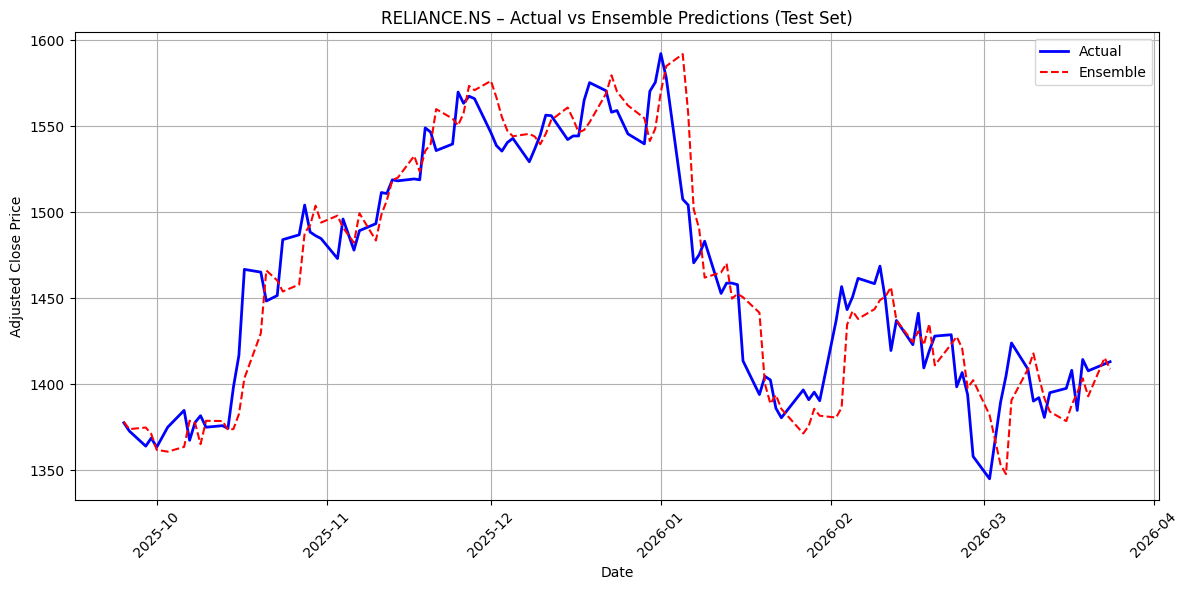


Done.


In [3]:
"""
panel_models.py
---------------
Trains pooled models (Ridge, Lasso, LightGBM, and an ensemble) on a universe of stocks.
Uses lagged prices (Adj Close, Open, High, Low), RSI, and stock_id as features.
Evaluates out‑of‑sample performance.
"""

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# ==============================
# 1. Define stock universe
# ==============================
TICKERS = [
    "RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS",
    "ICICIBANK.NS", "HINDUNILVR.NS", "ITC.NS", "SBIN.NS", "ASHOKLEY.NS"
]

# ==============================
# 2. Download and reshape data
# ==============================
print("Downloading data...")
df_raw = yf.download(TICKERS, period="5y", auto_adjust=False)

# df_raw has MultiIndex columns: (PriceType, Ticker)
# Stack the Ticker level into rows, then reset index
df_long = df_raw.stack(level=1).reset_index()
# Rename columns: first two are Date and Ticker, rest are price types
df_long.columns = ['Date', 'Ticker'] + list(df_long.columns[2:])
# Ensure the price type columns are exactly the ones we need
price_cols = ['Adj Close', 'Open', 'High', 'Low']
# Keep only needed columns (some might be missing? yfinance usually has all)
df_long = df_long[['Date', 'Ticker'] + price_cols]
# Convert Date to datetime and sort
df_long['Date'] = pd.to_datetime(df_long['Date'])
df_long = df_long.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f"Data shape: {df_long.shape}")
print(df_long.head())

# ==============================
# 3. Feature engineering (per stock)
# ==============================
def compute_RSI(series, window=14):
    """Compute RSI for a price series."""
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=window-1, adjust=False).mean()
    avg_loss = loss.ewm(com=window-1, adjust=False).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Create lag features for each price column (odd lags 1,3,5,7,9)
for col in price_cols:
    for i in range(1, 10, 2):
        df_long[f'lag_{i}_{col.replace(" ", "_")}'] = df_long.groupby('Ticker')[col].shift(i)

# Compute RSI on the Adj Close (we'll use the series of Adj Close, not a lag)
df_long['RSI'] = df_long.groupby('Ticker')['Adj Close'].transform(compute_RSI)

# Drop rows with NaN (first few days of each stock)
df_long.dropna(inplace=True)

print(f"After feature engineering, shape: {df_long.shape}")

# ==============================
# 4. Prepare features and target
# ==============================
# Target: next day's Adj Close (shift -1)
df_long['target'] = df_long.groupby('Ticker')['Adj Close'].shift(-1)
df_long.dropna(subset=['target'], inplace=True)

# Features: all lag columns + RSI
feature_cols = [col for col in df_long.columns if col.startswith('lag_')] + ['RSI']
X = df_long[feature_cols].copy()
y = df_long['target']
# Add stock_id as a categorical feature (for LightGBM)
X['stock_id'] = df_long['Ticker'].astype('category')

# ==============================
# 5. Train/test split (chronological)
# ==============================
# Use the last 10% of dates as test set
dates = df_long['Date'].unique()
dates_sorted = np.sort(dates)
split_idx = int(0.9 * len(dates_sorted))
train_dates = dates_sorted[:split_idx]
test_dates = dates_sorted[split_idx:]

train_mask = df_long['Date'].isin(train_dates)
test_mask = df_long['Date'].isin(test_dates)

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Train dates: {train_dates[0]} to {train_dates[-1]}")
print(f"Test dates: {test_dates[0]} to {test_dates[-1]}")

# ==============================
# 6. Define evaluation function
# ==============================
def evaluate(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mape": (np.abs((y_true - y_pred) / y_true)).mean() * 100,
        "r2": r2_score(y_true, y_pred)
    }

# ==============================
# 7. Train models
# ==============================
results = {}

# ---- Ridge (regularized linear) ----
print("\nTraining Ridge...")
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
ridge_pipeline.fit(X_train[feature_cols], y_train)   # stock_id not used for linear
y_pred_ridge = ridge_pipeline.predict(X_test[feature_cols])
results['Ridge'] = evaluate(y_test, y_pred_ridge)

# ---- Lasso ----
print("Training Lasso...")
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.01, max_iter=10000))
])
lasso_pipeline.fit(X_train[feature_cols], y_train)
y_pred_lasso = lasso_pipeline.predict(X_test[feature_cols])
results['Lasso'] = evaluate(y_test, y_pred_lasso)

# ---- LightGBM (with categorical stock_id) ----
print("Training LightGBM...")
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()
X_train_lgb['stock_id'] = X_train_lgb['stock_id'].cat.codes
X_test_lgb['stock_id'] = X_test_lgb['stock_id'].cat.codes

lgb_train = lgb.Dataset(X_train_lgb, y_train, categorical_feature=['stock_id'])
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}
lgb_model = lgb.train(params, lgb_train, valid_sets=[lgb_train], num_boost_round=200)
y_pred_lgb = lgb_model.predict(X_test_lgb)
results['LightGBM'] = evaluate(y_test, y_pred_lgb)

# ---- Ensemble (average of all three) ----
y_pred_ensemble = (y_pred_ridge + y_pred_lasso + y_pred_lgb) / 3
results['Ensemble'] = evaluate(y_test, y_pred_ensemble)

# ==============================
# 8. Print results
# ==============================
print("\n" + "="*60)
print("Model Performance on Test Set")
print("="*60)
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    print(f"  MAE:  {metrics['mae']:.4f}")
    print(f"  RMSE: {metrics['rmse']:.4f}")
    print(f"  MAPE: {metrics['mape']:.2f}%")
    print(f"  R²:   {metrics['r2']:.4f}")

# ==============================
# 9. Feature importance (LightGBM)
# ==============================
lgb_feature_imp = pd.DataFrame({
    'feature': X_train_lgb.columns,
    'importance': lgb_model.feature_importance()
}).sort_values('importance', ascending=False)

print("\nLightGBM Feature Importance:")
print(lgb_feature_imp.head(10))

# ==============================
# 10. Visualize predictions (optional)
# ==============================
sample_ticker = TICKERS[0]
test_ticker_mask = df_long.loc[test_mask, 'Ticker'] == sample_ticker
if test_ticker_mask.any():
    plt.figure(figsize=(12, 6))
    y_test_ticker = y_test[test_ticker_mask].values
    dates_ticker = df_long.loc[test_mask, 'Date'][test_ticker_mask].values
    
    plt.plot(dates_ticker, y_test_ticker, label='Actual', color='blue', linewidth=2)
    plt.plot(dates_ticker, y_pred_ensemble[test_ticker_mask], label='Ensemble', linestyle='--', color='red')
    plt.title(f'{sample_ticker} – Actual vs Ensemble Predictions (Test Set)')
    plt.xlabel('Date')
    plt.ylabel('Adjusted Close Price')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print("\nDone.")


LightGBM Feature Importance:
            feature  importance
0   lag_1_Adj_Close        1143
20              RSI         930
4   lag_9_Adj_Close         472
1   lag_3_Adj_Close         335
3   lag_7_Adj_Close         285
10       lag_1_High         275
2   lag_5_Adj_Close         238
15        lag_1_Low         229
14       lag_9_High         198
12       lag_5_High         177


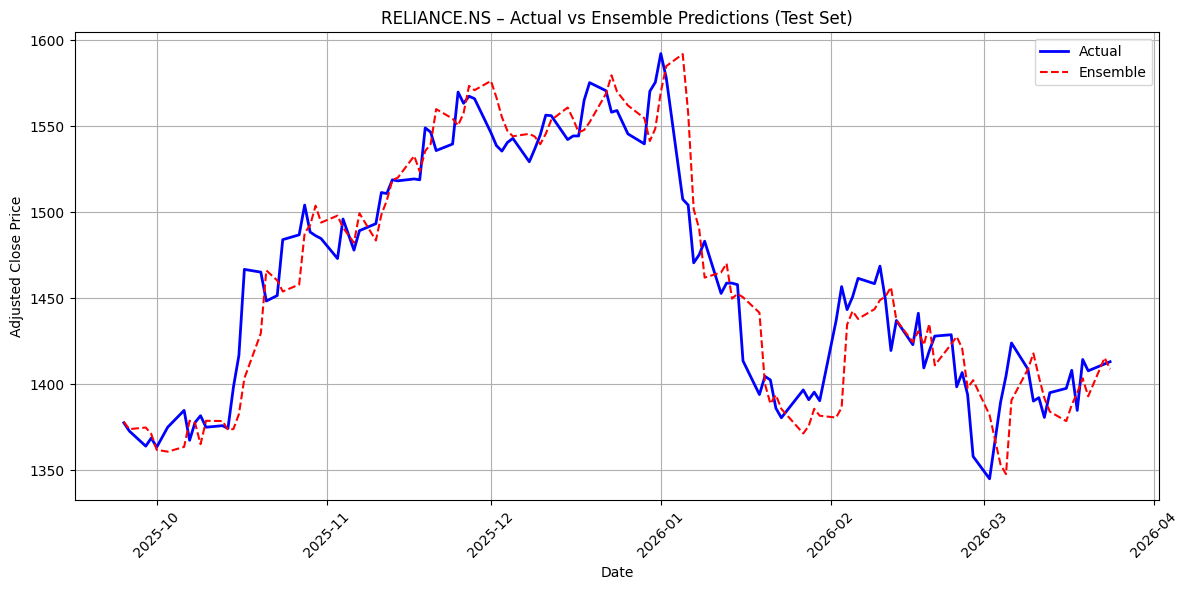

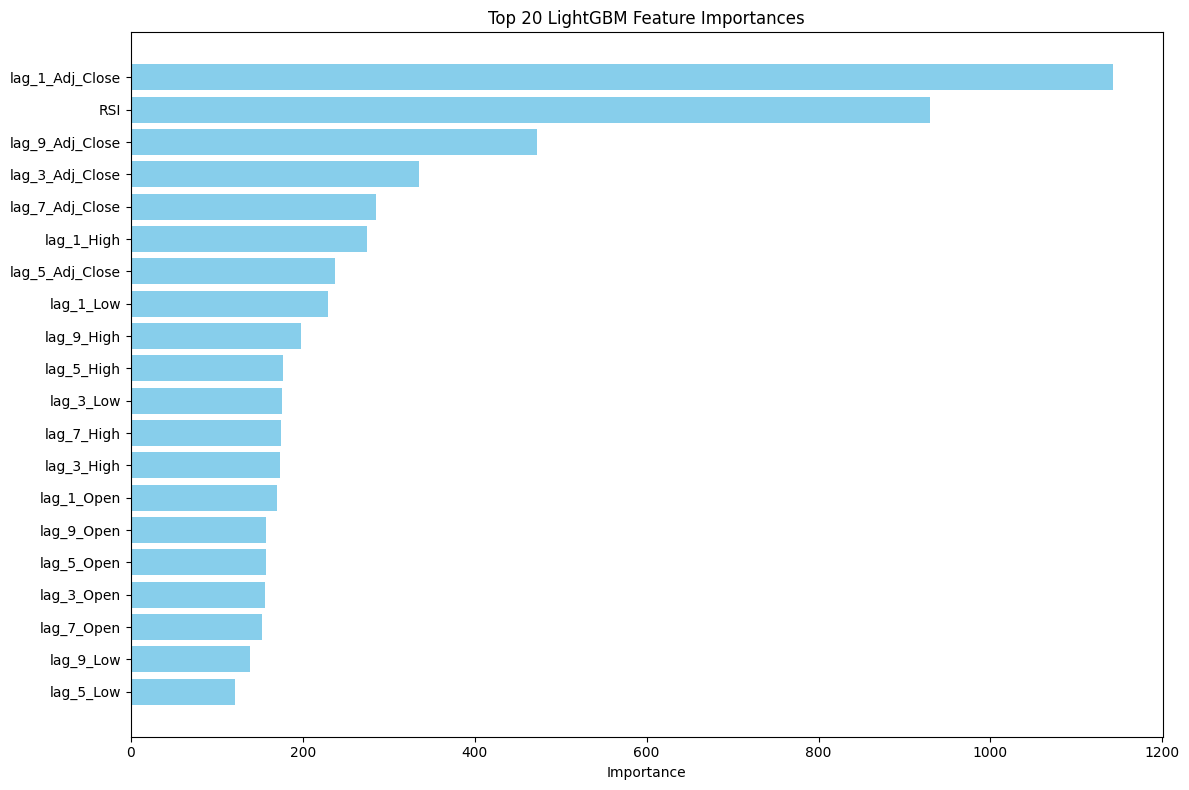


Done.


In [4]:
# ==============================
# 9. Feature importance (LightGBM)
# ==============================
lgb_feature_imp = pd.DataFrame({
    'feature': X_train_lgb.columns,
    'importance': lgb_model.feature_importance()
}).sort_values('importance', ascending=False)

print("\nLightGBM Feature Importance:")
print(lgb_feature_imp.head(10))

# ==============================
# 10. Visualize predictions (optional)
# ==============================
sample_ticker = TICKERS[0]
test_ticker_mask = df_long.loc[test_mask, 'Ticker'] == sample_ticker
if test_ticker_mask.any():
    plt.figure(figsize=(12, 6))
    y_test_ticker = y_test[test_ticker_mask].values
    dates_ticker = df_long.loc[test_mask, 'Date'][test_ticker_mask].values
    
    plt.plot(dates_ticker, y_test_ticker, label='Actual', color='blue', linewidth=2)
    plt.plot(dates_ticker, y_pred_ensemble[test_ticker_mask], label='Ensemble', linestyle='--', color='red')
    plt.title(f'{sample_ticker} – Actual vs Ensemble Predictions (Test Set)')
    plt.xlabel('Date')
    plt.ylabel('Adjusted Close Price')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==============================
# 11. Visualize feature importance
# ==============================
plt.figure(figsize=(12, 8))
top_features = lgb_feature_imp.head(20)
plt.barh(top_features['feature'], top_features['importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 20 LightGBM Feature Importances')
plt.gca().invert_yaxis()  # Show highest importance at the top
plt.tight_layout()
plt.show()

print("\nDone.")


Recursive 5‑day forecasts using ensemble model
Ensemble RMSE on test set: 31.0296

RELIANCE.NS – Next 5 trading day predictions:
  2026-03-26: 1095.38
  2026-03-27: 871.59
  2026-03-30: 720.39
  2026-03-31: 604.51
  2026-04-01: 516.73

TCS.NS – Next 5 trading day predictions:
  2026-03-26: 1888.59
  2026-03-27: 1525.42
  2026-03-30: 1276.14
  2026-03-31: 1098.22
  2026-04-01: 902.56

HDFCBANK.NS – Next 5 trading day predictions:
  2026-03-26: 623.59
  2026-03-27: 514.25
  2026-03-30: 436.99
  2026-03-31: 377.51
  2026-04-01: 334.12

INFY.NS – Next 5 trading day predictions:
  2026-03-26: 990.50
  2026-03-27: 791.65
  2026-03-30: 652.32
  2026-03-31: 551.03
  2026-04-01: 473.05

ICICIBANK.NS – Next 5 trading day predictions:
  2026-03-26: 980.09
  2026-03-27: 785.39
  2026-03-30: 649.11
  2026-03-31: 549.35
  2026-04-01: 472.21

HINDUNILVR.NS – Next 5 trading day predictions:
  2026-03-26: 1681.12
  2026-03-27: 1365.63
  2026-03-30: 1152.64
  2026-03-31: 939.89
  2026-04-01: 793.93

IT

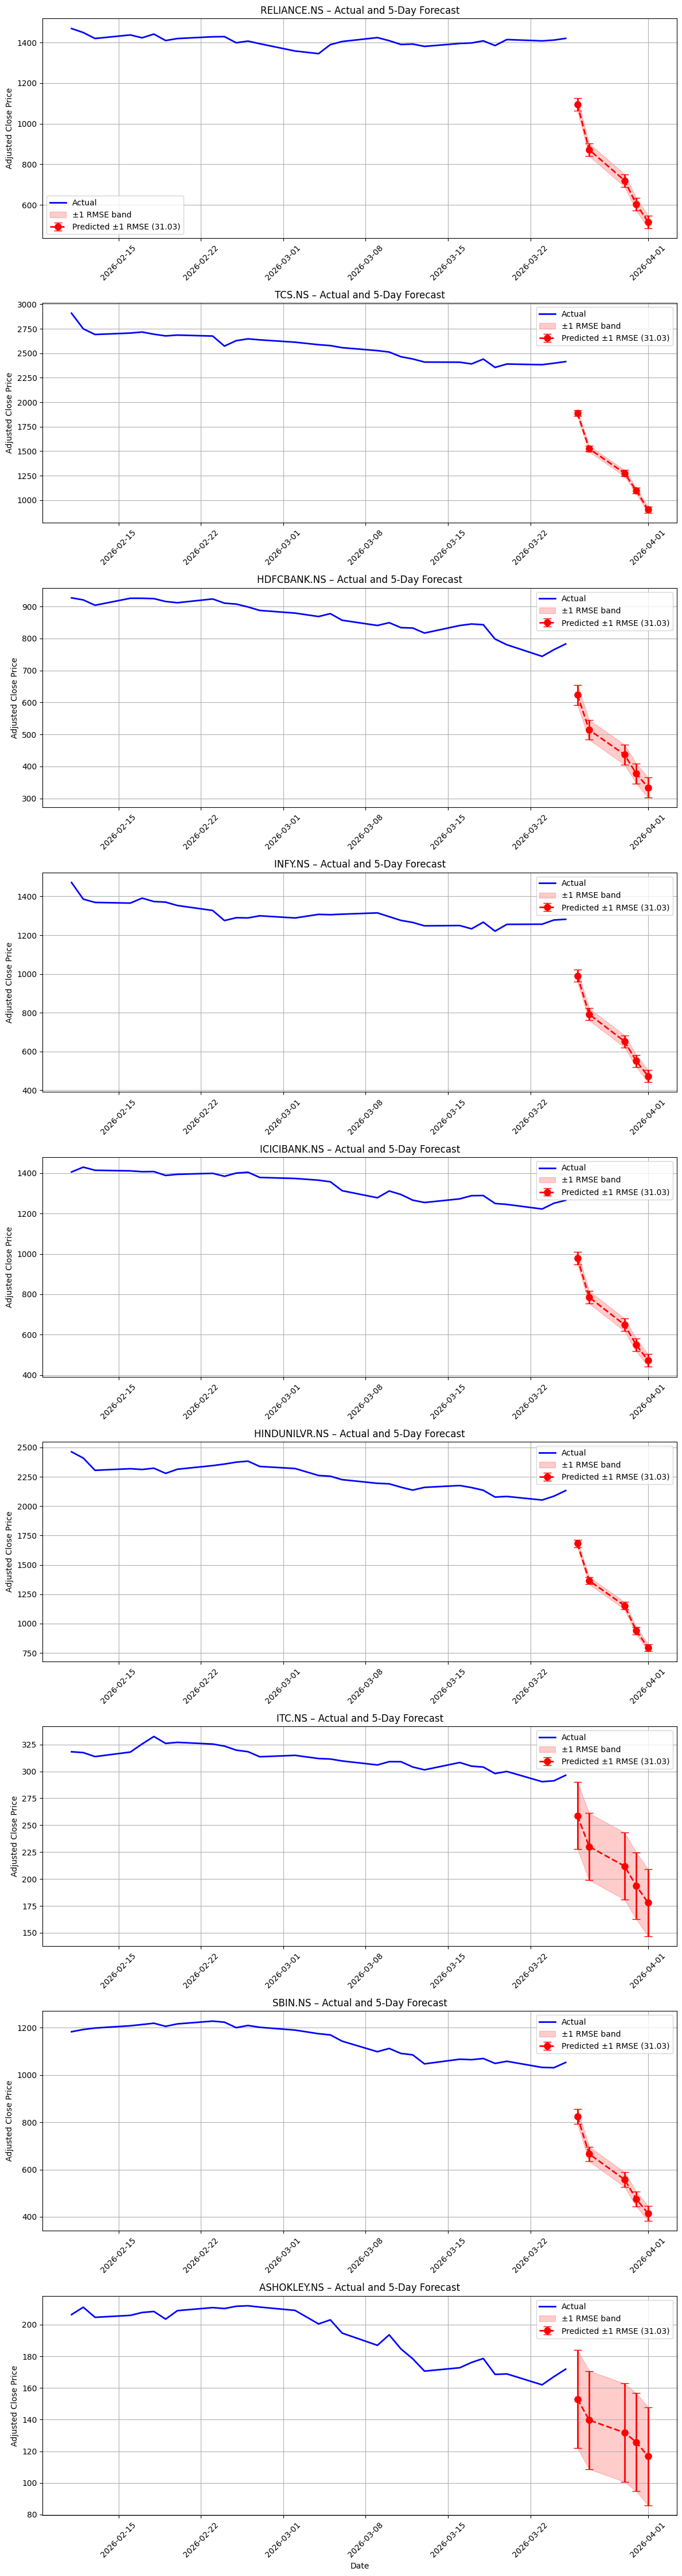


All forecasts generated.


In [2]:
# ==============================
# 11. Recursive forecasting for next 5 days for each stock
# ==============================
print("\n" + "="*60)
print("Recursive 5‑day forecasts using ensemble model")
print("="*60)

# Helper function for ensemble prediction
def ensemble_predict(features_df):
    """
    features_df: DataFrame with one row and columns: lag_1, lag_3, lag_5, lag_7, lag_9, RSI, stock_id
    Returns: predicted price (float)
    """
    # Extract numeric features for linear models
    X_num = features_df[feature_cols]
    # Ridge and Lasso predictions
    pred_ridge = ridge_pipeline.predict(X_num)[0]
    pred_lasso = lasso_pipeline.predict(X_num)[0]

    # LightGBM needs stock_id as numeric (already categorical codes)
    X_lgb = features_df[['stock_id'] + feature_cols].copy()
    # Ensure stock_id is integer (if not already)
    X_lgb['stock_id'] = X_lgb['stock_id'].cat.codes
    pred_lgb = lgb_model.predict(X_lgb)[0]

    # Ensemble average
    return (pred_ridge + pred_lasso + pred_lgb) / 3

# Use the ensemble RMSE from test set as uncertainty estimate
ensemble_rmse = results['Ensemble']['rmse']
print(f"Ensemble RMSE on test set: {ensemble_rmse:.4f}")

# For each stock, generate forecast
forecasts = {}   # stock -> {'dates': list, 'predictions': list}

for ticker in TICKERS:
    # Get full price history for this stock
    prices = df_raw[ticker].dropna().tolist()   # actual prices
    last_date = df_raw[ticker].dropna().index[-1]

    # Generate next 5 trading days (business days)
    future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=5)

    predictions = []
    # For recursive prediction, we need to extend the price list
    price_list = prices.copy()

    for _ in range(5):
        if len(price_list) < 9:
            print(f"Error: Not enough historical prices for {ticker}.")
            break

        # Extract lags
        lag_1 = price_list[-1]
        lag_3 = price_list[-3]
        lag_5 = price_list[-5]
        lag_7 = price_list[-7]
        lag_9 = price_list[-9]

        # Compute RSI on the whole price series (including predicted)
        price_series = pd.Series(price_list)
        rsi_val = compute_RSI(price_series).iloc[-1]

        # Build feature dictionary
        feature_dict = {
            'lag_1': lag_1,
            'lag_3': lag_3,
            'lag_5': lag_5,
            'lag_7': lag_7,
            'lag_9': lag_9,
            'RSI': rsi_val,
            'stock_id': ticker
        }

        # Create a DataFrame with one row
        features_df = pd.DataFrame([feature_dict])
        features_df['stock_id'] = features_df['stock_id'].astype('category')

        # Predict
        next_price = ensemble_predict(features_df)
        predictions.append(next_price)
        price_list.append(next_price)

    forecasts[ticker] = {
        'dates': future_dates,
        'predictions': predictions,
        'last_actual_date': last_date,
        'actual_prices': prices
    }

    # Display predictions
    print(f"\n{ticker} – Next 5 trading day predictions:")
    for date, price in zip(future_dates, predictions):
        print(f"  {date.strftime('%Y-%m-%d')}: {price:.2f}")

# ==============================
# 12. Visualize forecasts with uncertainty bands
# ==============================
# Create subplots: one row per stock
n_stocks = len(TICKERS)
fig, axes = plt.subplots(n_stocks, 1, figsize=(12, 5 * n_stocks), sharex=False)

if n_stocks == 1:
    axes = [axes]

for idx, ticker in enumerate(TICKERS):
    ax = axes[idx]
    fcast = forecasts[ticker]
    # Last 30 actual prices (or fewer if not enough)
    actual_prices = fcast['actual_prices']
    actual_dates = df_raw[ticker].dropna().index[-len(actual_prices):]
    # Plot actual
    ax.plot(actual_dates[-30:], actual_prices[-30:],
            label='Actual', color='blue', linewidth=2)
    # Plot forecast with error bars
    future_dates = fcast['dates']
    preds = fcast['predictions']
    ax.errorbar(future_dates, preds, yerr=ensemble_rmse, fmt='ro--',
                capsize=5, markersize=8, linewidth=2,
                label=f'Predicted ±1 RMSE ({ensemble_rmse:.2f})')
    # Shaded confidence band
    ax.fill_between(future_dates,
                    [p - ensemble_rmse for p in preds],
                    [p + ensemble_rmse for p in preds],
                    color='red', alpha=0.2, label='±1 RMSE band')
    ax.set_title(f'{ticker} – Actual and 5‑Day Forecast')
    ax.set_ylabel('Adjusted Close Price')
    ax.legend()
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

print("\nAll forecasts generated.")